# First model: Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. The inherent problem of this project is unsupervised, therefore we consider a range of unsupervised models, starting off with clustering.

In [470]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [471]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from data import utils

## Load Data

In [472]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])


In [473]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])


### Extracting Anomaly Data

In [610]:
# Extract extreme drought years 2018, 2019

def get_anomaly_df(df):
    df = rem_year(df, 2019, 2025)
    mask = df["Timestamp"].dt.year.isin([2018])
    return df[~mask].copy(), df[mask].copy()

def rem_year(df, year, *years):
    all_years = [year, *years]
    mask = df["Timestamp"].dt.year.isin(all_years)
    return df[~mask]

In [611]:
norm_ns_df, anom_ns_df = get_anomaly_df(non_spectral_df)
norm_s_df, anom_s_df = get_anomaly_df(grouped_spectral_df[["Timestamp", "NDVI_mean", "NDWI_mean", "NDRE_mean",]])

norm_eng_ns_df, anom_eng_ns_df = get_anomaly_df(eng_non_spectral_df)
norm_roll_lag_df, anom_roll_lag_df = get_anomaly_df(roll_lag_df)

### Interpolation

We present the first issue of our data using a simple merge between the non-spectral and spectral datasets.

In [612]:
master_raw_df = grouped_spectral_df.merge(non_spectral_df, on="Timestamp" ,how='right')
master_raw_df.head(7)

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation
0,2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,284.922923,301.389491,3.288490e+07,0.000000
1,2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,285.298415,295.811490,3.127135e+07,0.000000
2,2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,283.975136,296.656369,2.872766e+07,0.000000
3,2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,283.692780,298.823837,3.154392e+07,2.618651
4,2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,284.633106,302.508414,3.183471e+07,1.835338
5,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,0.290550,0.332584,0.298607,0.270337,296.744157,295.314101,293.286606,291.108126,295.740201,285.324435,304.907338,3.151798e+07,0.000000
6,2018-01-07,0.454175,0.017789,0.15485,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000


You will quickly notice that our spectral indices contain lots of `NaN` observations. This is due to the almost-weekly passes of the Sentinel-2 mission, as well as cloud-masking applied in our pre-processing steps. Luckily, NDVI follows a pretty general pattern and is not prone to extreme oscilations from one moment to the next. It is therefore not a bad idea to use the built-in **Cubic Hermit Spline** wrapper to `scipy` in `pandas` to account for these unobserved images. 

Note we also use **backfilling** to account for the missing observations at the start of our datasets, as the spectral indices are unlikely to vary much in such a short period.

In [613]:
def get_interpolated_df(spectral, timestamps):
    spectral_columns = [
        "NDVI_mean",
        "NDWI_mean",
        "NDRE_mean",
    ]

    df = spectral.merge(timestamps, on="Timestamp", how="right")
    interpolated_df = df[["Timestamp"] + spectral_columns].copy()
    interpolated_df[spectral_columns] = interpolated_df[spectral_columns].interpolate(method="pchip", limit_area="inside").bfill()

    return interpolated_df.dropna()

We create a function because we will be applying the interpolation to the anomaly dataset and the "normal"/expected dataset separately. Why? To prevent data leakage and noisy estimates. More specifically:

- There is a large chunk of observations missing around the hard split induced for the drought years 2018-2019. If we interpolate the full dataset first, ~90 days worth of observations will have _interpolated_ data points. It goes without saying that interpolation will absolutely **not** be able to reliably "estimate" 90 days of missing vegetation indices.
- Interpolating the data points around the split will carry over data from the _drought_ period to the _normal_ period. Our model will then have been exposed already to the drought conditions during its training. This is something that should rather be avoided.

We can theoretically solve this issue by building a regression model and filling large chunks (say $n>5$) of empty observations with predictions. For right now, we prioritise the unsupervised model first and therefore drop the empty observations.

In [614]:
norm_interpolated_df = get_interpolated_df(spectral=norm_s_df, timestamps=norm_eng_ns_df["Timestamp"])
norm_interpolated_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean
0,2020-01-01,0.510191,0.162344,0.338149
1,2020-01-02,0.510191,0.162344,0.338149
2,2020-01-03,0.513993,0.168500,0.341483
3,2020-01-04,0.517872,0.174706,0.344836
4,2020-01-05,0.521828,0.180961,0.348206


In [615]:
anom_interpolated_df = get_interpolated_df(spectral=anom_s_df, timestamps=anom_eng_ns_df["Timestamp"])
anom_interpolated_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean
0,2018-01-01,0.454175,0.15485,0.301027
1,2018-01-02,0.454175,0.15485,0.301027
2,2018-01-03,0.454175,0.15485,0.301027
3,2018-01-04,0.454175,0.15485,0.301027
4,2018-01-05,0.454175,0.15485,0.301027


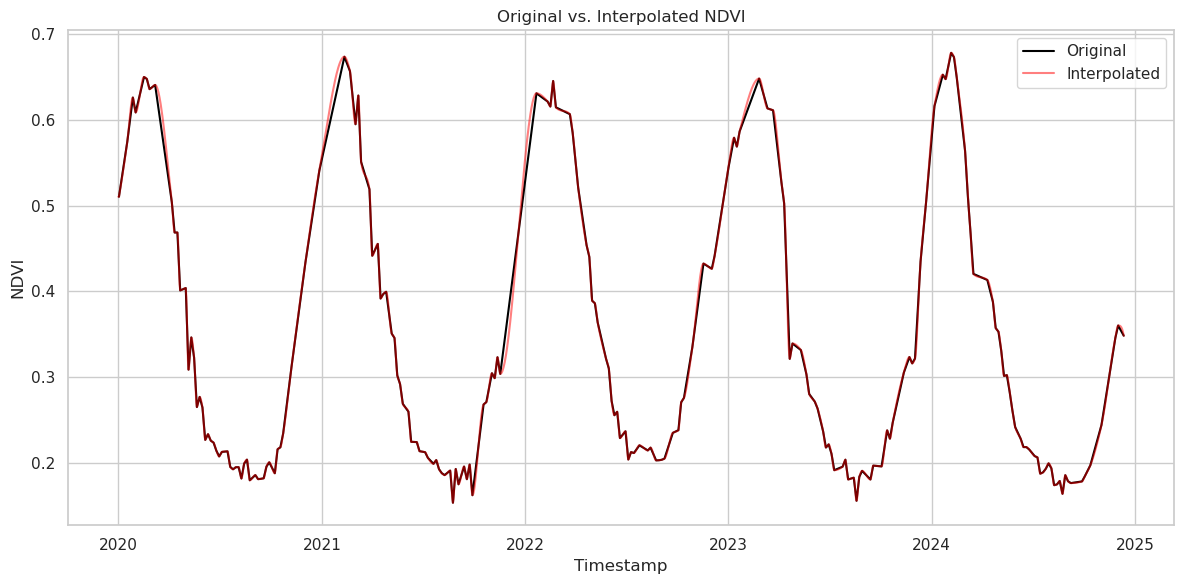

In [616]:
plot_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
plot_df, _ = get_anomaly_df(plot_df)
plt.figure(figsize=(12, 6))
plt.title("Original vs. Interpolated NDVI")
sns.lineplot(x=plot_df["Timestamp"], y=plot_df["NDVI_mean"], label="Original", c="black")
sns.lineplot(x=norm_interpolated_df["Timestamp"], y=norm_interpolated_df["NDVI_mean"], label="Interpolated", c="red", alpha=0.5)

plt.xlabel("Timestamp")
plt.ylabel("NDVI")
plt.legend()
plt.tight_layout()
plt.show()

---

## Full Model, no lagged variables or rolling statistics

As a baseline, we fit a GMM on all our engineered and remaining non-spectral variables. The log likelihood of the training sample will give us a good indication of how well the model fit to the data. Note that, since GMM's assume _continuous_ variables, we do not explicitly make use of the `in_season` or `Growth-Stage` features. We will operate under the assumption that this information is baked into `cummulative_GDD`.

In [617]:
eng_features = [
    # Timestamp for merging
    'Timestamp',

    # Date features for plotting
    "doy",
    "year",

    # engineered features
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    #'VW_PC1',  
    #'Shallow_mean',
    'ST_PC1'

    # Categoricals not included
    #'Growth_Stage',
    #'in_season',
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation',
    #'volumetric_soil_water_layer_3',
    #'volumetric_soil_water_layer_4',
    'soil_temperature_level_4'
]


In [618]:
# Get normal data
X_part1 = norm_eng_ns_df[eng_features]
X_part2 = norm_ns_df[non_spectral_features]
X_non_spectral_norm = pd.merge(X_part2, X_part1, on="Timestamp")

# Merge with interpolated spectral dataframe
X_norm = norm_interpolated_df.merge(X_non_spectral_norm, on="Timestamp", how="left")
X_norm['doy_sin'] = np.sin(2 * np.pi * X_norm['doy'] / 365.25)
X_norm['doy_cos'] = np.cos(2 * np.pi * X_norm['doy'] / 365.25)

X_norm.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,soil_temperature_level_4,doy,year,cumulative_GDD,root_weighted_soil_moisture,ST_PC1,doy_sin,doy_cos
0,2020-01-01,0.510191,0.162344,0.338149,294.218560,289.641174,300.815842,2.342209e+07,5.768824,292.505906,1,2020,668.434571,0.323509,1.862650,0.017202,0.999852
1,2020-01-02,0.510191,0.162344,0.338149,294.688144,288.120487,302.366209,2.902789e+07,0.458307,292.525425,2,2020,680.527919,0.318876,2.056825,0.034398,0.999408
2,2020-01-03,0.513993,0.168500,0.341483,295.368853,287.284957,302.610221,2.969595e+07,7.398956,292.546249,3,2020,692.325508,0.311703,2.200804,0.051584,0.998669
3,2020-01-04,0.517872,0.174706,0.344836,295.601588,288.227640,302.926995,3.014462e+07,12.979295,292.568757,4,2020,704.752826,0.304541,2.330165,0.068755,0.997634
4,2020-01-05,0.521828,0.180961,0.348206,295.907643,288.903460,302.875189,3.009218e+07,2.838473,292.593196,5,2020,717.492150,0.299192,2.435835,0.085906,0.996303


In [619]:
# Get anomaly data

X_part1 = anom_eng_ns_df[eng_features]
X_part2 = anom_ns_df[non_spectral_features]
X_ns_anom = pd.merge(X_part2, X_part1, on="Timestamp")

# Merge with interpolated spectral dataframe
X_anom = anom_interpolated_df.merge(X_ns_anom, on="Timestamp", how="left")
X_anom['doy_sin'] = np.sin(2 * np.pi * X_norm['doy'] / 365.25)
X_anom['doy_cos'] = np.cos(2 * np.pi * X_norm['doy'] / 365.25)

X_anom.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,soil_temperature_level_4,doy,year,cumulative_GDD,root_weighted_soil_moisture,ST_PC1,doy_sin,doy_cos
0,2018-01-01,0.454175,0.15485,0.301027,293.314439,284.922923,301.389491,3.288490e+07,0.000000,290.955942,1,2018,10.006207,0.0,1.550109,0.017202,0.999852
1,2018-01-02,0.454175,0.15485,0.301027,289.883795,285.298415,295.811490,3.127135e+07,0.000000,290.987094,2,2018,17.411159,0.0,1.465590,0.034398,0.999408
2,2018-01-03,0.454175,0.15485,0.301027,290.475579,283.975136,296.656369,2.872766e+07,0.000000,291.017846,3,2018,24.576912,0.0,1.450933,0.051584,0.998669
3,2018-01-04,0.454175,0.15485,0.301027,291.254956,283.692780,298.823837,3.154392e+07,2.618651,291.047929,4,2018,32.685221,0.0,1.541121,0.068755,0.997634
4,2018-01-05,0.454175,0.15485,0.301027,293.653434,284.633106,302.508414,3.183471e+07,1.835338,291.077664,5,2018,43.105980,0.0,1.741368,0.085906,0.996303


### Training

Now begins our training process. Expectations for this baseline model are not high due to there not being any consideration for correlation, lagging variables or rolling statistics. 

In [620]:
X = X_norm.drop(["Timestamp", "doy", "year", "doy_sin", "doy_cos"], axis=1).copy()
Xa = X_anom.drop(["Timestamp", "doy", "year", "doy_sin", "doy_cos"], axis=1).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X_norm.index)
X_scaled_df = pd.concat([X_scaled_df, X_norm[["doy_sin", "doy_cos"]]], axis=1)

X_anom_scaled = scaler.transform(Xa)
X_anom_df = pd.DataFrame(X_anom_scaled, columns=Xa.columns, index=X_anom.index)
X_anom_df = pd.concat([X_anom_df, X_anom[["doy_sin", "doy_cos"]]], axis=1)

split_i = X_norm.index[X_norm["year"] == 2024][0]
X_train = X_scaled_df.loc[:split_i]
X_test = X_scaled_df.iloc[split_i:]


In [621]:
X_test.shape

(346, 14)

In [622]:

covariance_types = ['full', 'tied', 'diag']
components = range(1, 50)
bics = np.zeros(shape=(len(covariance_types), len(components)))

min_bic = np.inf
min_bic_k = 0
best_cov = None
best_model = None


for i, cov in enumerate(covariance_types):
    for j, k in enumerate(components):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=10)
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        bics[i, j] = bic
        if bic < min_bic:
            min_bic = bic
            min_bic_k = k
            best_cov = cov
            best_model = gmm

print(f"Minimum BIC: {min_bic} with {min_bic_k} components and '{best_cov}' Covariance Matrices.")

Minimum BIC: -22925.78124128442 with 10 components and 'full' Covariance Matrices.


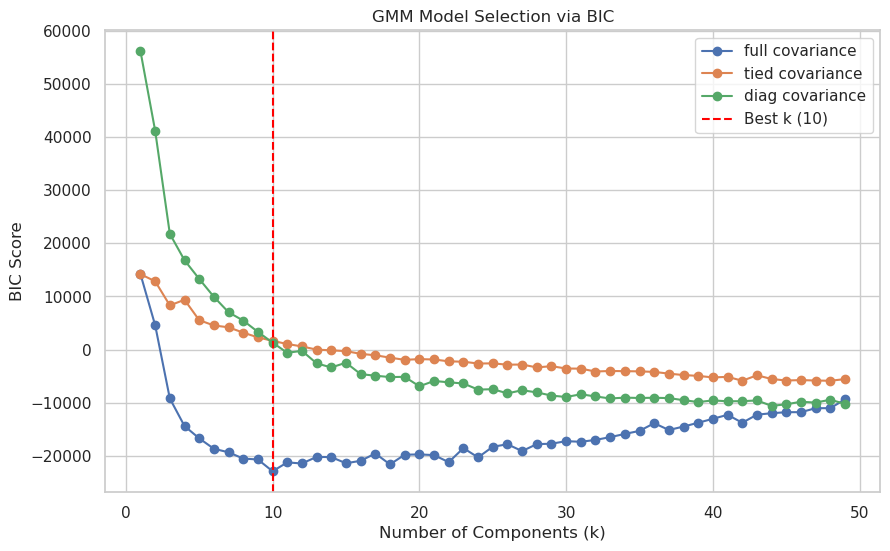

In [623]:
plt.figure(figsize=(10, 6))
for i, cov in enumerate(covariance_types):
    plt.plot(components, bics[i], label=f'{cov} covariance', marker='o')

plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("GMM Model Selection via BIC")
plt.axvline(x=min_bic_k, color='red', linestyle='--', label=f'Best k ({min_bic_k})')
plt.legend()
plt.grid(True)
plt.show()

While $k=15$ provides us with the lowest BIC, the graph shows that the score stays relatively stable when $k\in[10, 20]$. This suggests that extra components are not improving $\log \ L$ enough to justify their complexity penalty. We therefore consider an 'elbow' model at $k=10$ (i.e. the point where BIC stabalises).   

In [624]:
elbow_k = 11

In [625]:
elbow_model = GaussianMixture(n_components=elbow_k, covariance_type='full', random_state=42, n_init=10).fit(X_train)

In [626]:
bic_test_score = best_model.score(X_test)
bic_anom_score = best_model.score(X_anom_df)

elbow_test_score = elbow_model.score(X_test)
elbow_anom_score = elbow_model.score(X_anom_df)

print(f"{'Metric':<35}{'Lowest BIC model':<25}{'Elbow model'}")
print("-" * 80)

print(f"{'Test data log-likelihood':<35}{bic_test_score:.2f}{'':<25}{elbow_test_score:.2f}")
print(f"{'Anomaly data log-likelihood':<35}{bic_anom_score:.2f}{'':<25}{elbow_anom_score:.2f}")

Metric                             Lowest BIC model         Elbow model
--------------------------------------------------------------------------------
Test data log-likelihood           -5.49                         -9.24
Anomaly data log-likelihood        -77.62                         -80.30


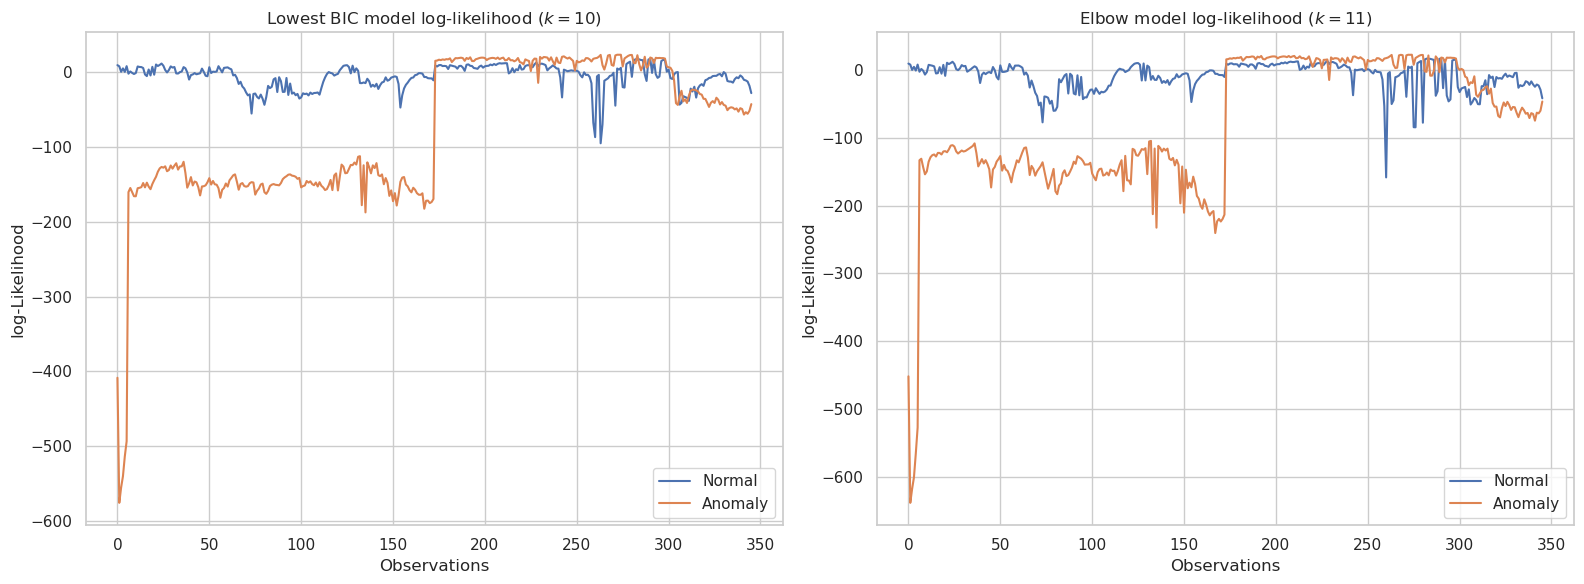

In [627]:
bic_test_scores = best_model.score_samples(X_test)
bic_anom_scores = best_model.score_samples(X_anom_df)

elbow_test_scores = elbow_model.score_samples(X_test)
elbow_anom_scores = elbow_model.score_samples(X_anom_df)



fig, ax = plt.subplots(ncols=2, figsize=(16, 6), sharey=False)
ax[0].set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
sns.lineplot(bic_test_scores, ax=ax[0], label="Normal")
sns.lineplot(bic_anom_scores[:len(X_test)], ax=ax[0], label="Anomaly")
ax[0].set_ylabel("log-Likelihood")
ax[0].set_xlabel("Observations")

ax[1].set_title(f"Elbow model log-likelihood ($k={elbow_k}$)")
sns.lineplot(elbow_test_scores, ax=ax[1], label="Normal")
sns.lineplot(elbow_anom_scores[:len(X_test)], ax=ax[1], label="Anomaly")
ax[1].set_ylabel("log-Likelihood")
ax[1].set_xlabel("Observations")
plt.tight_layout()
plt.show()

We also create density plots to better showcase the separation abilities of the two models:

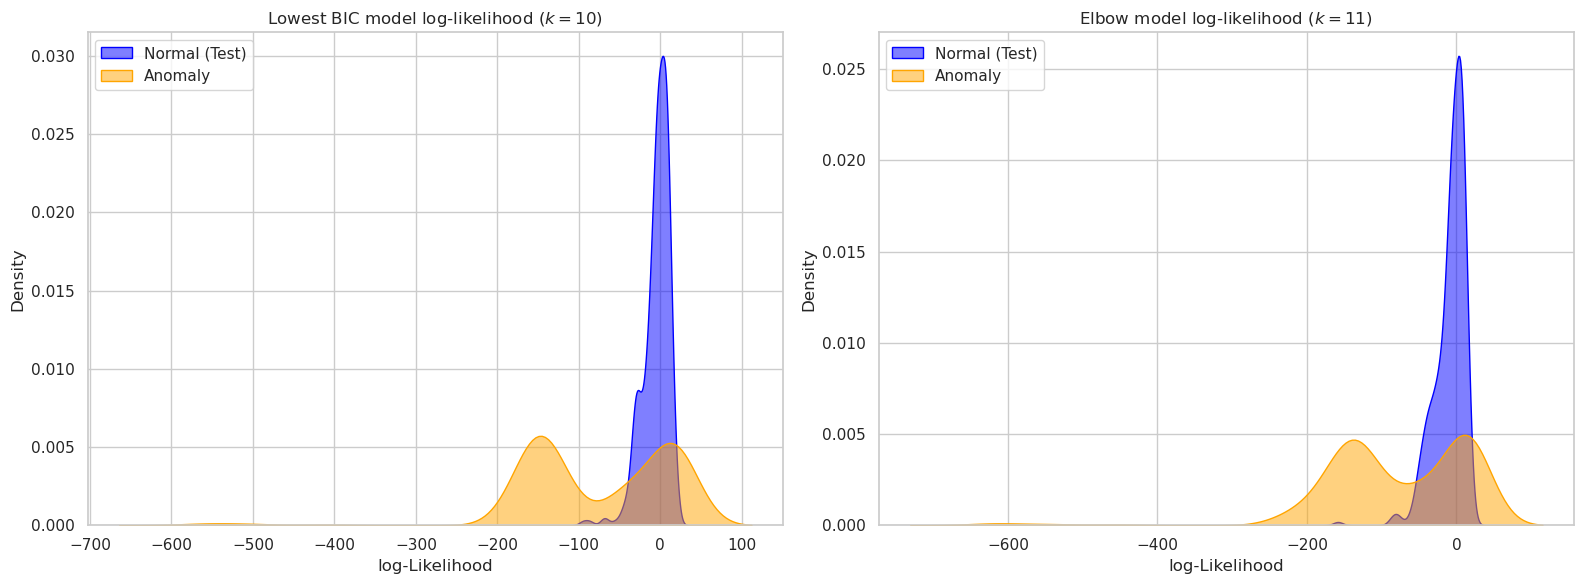

In [628]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), sharey=False)
ax[0].set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
sns.kdeplot(bic_test_scores, label="Normal (Test)", fill=True, color="blue", alpha=0.5, ax=ax[0])
sns.kdeplot(bic_anom_scores, label="Anomaly", fill=True, color="orange", alpha=0.5, ax=ax[0])
ax[0].set_ylabel("Density")
ax[0].set_xlabel("log-Likelihood")
ax[0].legend()

ax[1].set_title(f"Elbow model log-likelihood ($k={elbow_k}$)")
sns.kdeplot(elbow_test_scores, label="Normal (Test)", fill=True, color="blue", alpha=0.5, ax=ax[1])
sns.kdeplot(elbow_anom_scores, label="Anomaly", fill=True, color="orange", alpha=0.5, ax=ax[1])
ax[1].set_ylabel("Density")
ax[1].set_xlabel("log-Likelihood")
ax[1].legend()
plt.tight_layout()
plt.show()

The first thing to note is inevitably there will be overlap between the log-likelihoods since off-season looks the same no matter the weather conditions. 

Both models clearly assign lower log-likelihoods to anomalous data than to normal data, but they both have different tail behaviours. The model with $k=15$ components has anomaly scoring stretching down to $-25\ 000$ while the $k=10$ model stops at around $-6000$. The $k=10$ model has a density peak at $\sim 0.0014$ while the higher-order model is much lower at $\sim0.0005$. To explain this behaviour, it helps to look at the GMM log-likelihood formula 

$$\log p(\underline{x})=\log\left(\sum^k_{j=1}\pi_{j}N(\underline{x}|\underline{\mu}_{j}, \Sigma_{j}\right)$$

As the model becomes more flexible ($\uparrow k$),  _tighther_ clusters are formed, causing the variances $\Sigma_j$ of component $j$ to shrink to zero. This creates a density spike at the cluster center, but movement away from these components causes $\Sigma_j^{-1}$ to penalise the likelihood. This leads to anomaly points having extreme negative log-likelihoods. 

We can thus  make the following conclusions:

1. We cannot directly compare the likelihoods since these models have different $k$ components. We only consider the relative behaviours of the densities.
2. The $k=15$ model features low-variance components that aggressively penalise anomalous samples, resulting in low log-likelihood values. The model has strong detection signal for _some_ anomalies, but extremely large variance in the log-likelihood.
3. The $k=10$ model has a smoother likelihood curve, with fewer extreme penalties for unusual observations. This stability comes at a trade-off of weaker separation for harder-to-detect anomalies.




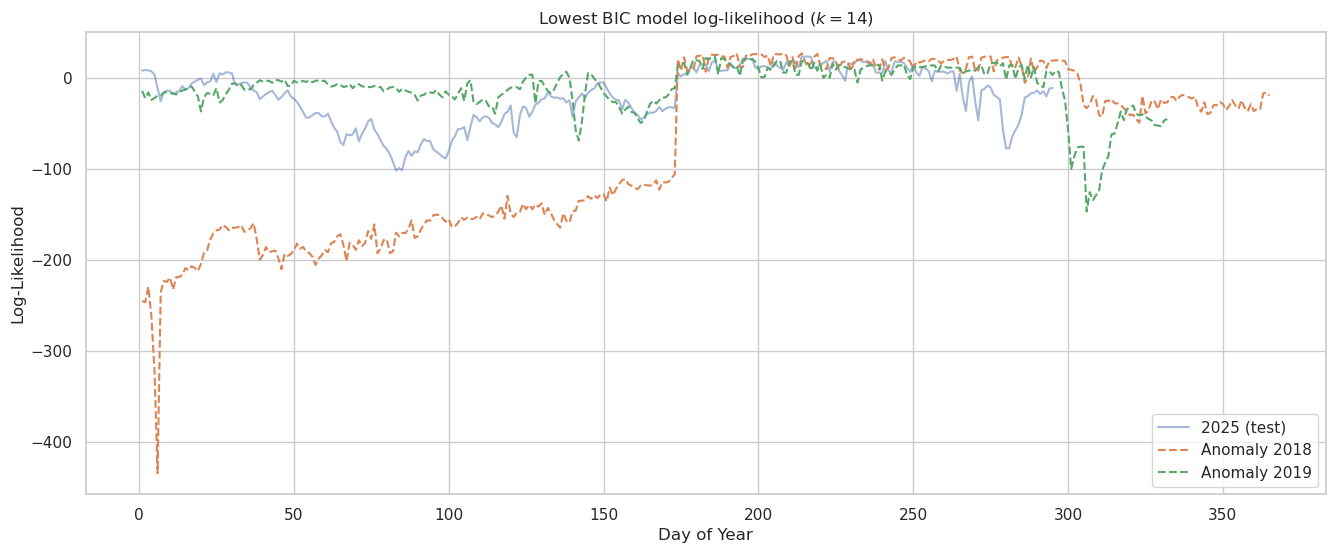

In [521]:
test_results = X_norm.iloc[split_i:][["year", "doy"]].copy()
test_results["log_likelihood"] = bic_test_scores
anom_results = X_anom[["year", "doy"]].copy()
anom_results["log_likelihood"] = bic_anom_scores

fig, ax = plt.subplots(figsize=(16, 6))

for year, group in test_results.groupby("year"):
    group = group.sort_values("doy")
    sns.lineplot(
        data=group,
        x="doy",
        y="log_likelihood",
        ax=ax,
        label=f"{str(year)} (test)",
        alpha=0.5
    )

for year, group in anom_results.groupby("year"):
    group = group.sort_values("doy")
    sns.lineplot(
        data=group,
        x="doy",
        y="log_likelihood",
        ax=ax,
        linestyle="--",
        label=f"Anomaly {year}"
    )


ax.set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("Log-Likelihood")
plt.show()

---

## Rolling and Lagged variables

While our first model does have pretty surprising performance, it does operate under two assumptions violated by the data:
1. **Independence between observations**:
2. **No temporal behaviour of variables**: The baseline GMM does not in any way use _past_ environmental data for _current_ observations during its clustering. This is a bad strategy for time series agricultural data because, for example, rain will not have a meaningful effect on a crop until a few days _after_ it has occurred. Similarly, a single day's drought will not put a plant under stress, but rather an _accumulation_ of days of drought.

While we cannot address the independence assumption since that is a defining characteristic of a GMM, we can include rolled statistics and lagging variables to force the model to learn on temporal data.

In [649]:
roll_lag_features = [
    "Timestamp",
    
    # Temperature
    #"temperature_2m_lag_7",
    #"temperature_2m_lag_30",
    "temperature_2m_7D_mean",
    "temperature_2m_30D_mean",

    # Solar radiation
    #"surface_solar_radiation_downwards_sum_lag_7",
    #"surface_solar_radiation_downwards_sum_lag_30",
    "surface_solar_radiation_downwards_sum_7D_sum",
    #"surface_solar_radiation_downwards_sum_30D_sum",

    # Precipitation
    #"precipitation_lag_7",
    #"precipitation_lag_30",
    "precipitation_7D_sum",
    "precipitation_30D_sum",

    

    # Root-zone soil moisture (linear comb of first 3 volumetric soil water layers)
    #"root_weighted_soil_moisture_lag_7",
    #"root_weighted_soil_moisture_lag_30",
    "root_weighted_soil_moisture_7D_mean",
    "root_weighted_soil_moisture_30D_mean",

    # Volumetric soil water layers 1 and 2 (shallow) (first PC)
    #"VW_PC1_lag_7",
    #"VW_PC1_lag_30",
    "VW_PC1_7D_mean",
    "VW_PC1_30D_mean",

    # Soil temperatre levels 1-3 (shallow) PCs
    #"ST_PC1_lag_7",
    #"ST_PC1_lag_30",
    "ST_PC1_7D_mean",
    "ST_PC1_30D_mean",

    # Soil temperatre levels 1-3 (shallow) mean 
    #"Shallow_mean_lag_7",
    #"Shallow_mean_lag_30",
    #"Shallow_mean_7D_mean",
    #"Shallow_mean_30D_mean",

    # Deep volumetric Soil Water Layers 3-4
    "volumetric_soil_water_layer_3_7D_mean",
    #"volumetric_soil_water_layer_3_30D_mean",
    "volumetric_soil_water_layer_4_7D_mean",
    #"volumetric_soil_water_layer_4_30D_mean",
    
    #'volumetric_soil_water_layer_3_lag_7',
    #'volumetric_soil_water_layer_3_lag_30',
    #'volumetric_soil_water_layer_4_lag_7',
    #'volumetric_soil_water_layer_4_lag_30',

    # Deep soil temperature level 4
    #"soil_temperature_level_4_7D_mean",
    #"soil_temperature_level_4_30D_mean",
    #'soil_temperature_level_4_lag_7',
    #'soil_temperature_level_4_lag_30'

]

eng_features = [
    # Date/time variables 
    'Timestamp',
    #"shifted_doy",
    "doy",
    "year",

    
    'cumulative_GDD', 
    #'root_weighted_soil_moisture', 
    #'VW_PC1', 
    #'Shallow_mean',
    #'ST_PC1'

    # Categoricals not valid for GMM
    #'in_season', 
    #'Growth_Stage',
    
]

non_spectral_features = [
    'Timestamp',
    #'temperature_2m',
    #'temperature_2m_min',
    'temperature_2m_max', 
    #'surface_solar_radiation_downwards_sum',
    'precipitation',
    #'volumetric_soil_water_layer_3',
    #'volumetric_soil_water_layer_4',
    #'soil_temperature_level_4'
]



In [650]:
# Get normal data
X_part1 = norm_eng_ns_df[eng_features]
X_part2 = norm_roll_lag_df[roll_lag_features]
X_part3 = norm_ns_df[non_spectral_features]

X_eng_norm = pd.merge(X_part2, X_part1, on="Timestamp")
X_non_spectral_norm = pd.merge(X_part3, X_eng_norm, on="Timestamp")


# Merge with interpolated spectral dataframe
X_norm = norm_interpolated_df.merge(X_non_spectral_norm, on="Timestamp", how="left")
X_norm['doy_sin'] = np.sin(2 * np.pi * X_norm['doy'] / 365.25)
X_norm['doy_cos'] = np.cos(2 * np.pi * X_norm['doy'] / 365.25)

X_norm.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m_max,precipitation,temperature_2m_7D_mean,temperature_2m_30D_mean,surface_solar_radiation_downwards_sum_7D_sum,precipitation_7D_sum,...,VW_PC1_30D_mean,ST_PC1_7D_mean,ST_PC1_30D_mean,volumetric_soil_water_layer_3_7D_mean,volumetric_soil_water_layer_4_7D_mean,doy,year,cumulative_GDD,doy_sin,doy_cos
0,2020-01-01,0.510191,0.162344,0.338149,300.815842,5.768824,292.737892,291.466043,1.454010e+08,26.941463,...,1.027959,1.756401,1.546544,0.287212,0.267709,1,2020,668.434571,0.017202,0.999852
1,2020-01-02,0.510191,0.162344,0.338149,302.366209,0.458307,292.622195,291.400187,1.471996e+08,27.277287,...,1.103581,1.738532,1.490804,0.287022,0.267705,2,2020,680.527919,0.034398,0.999408
2,2020-01-03,0.513993,0.168500,0.341483,302.610221,7.398956,292.835328,291.783831,1.540190e+08,34.676244,...,1.105838,1.753086,1.501186,0.286819,0.267702,3,2020,692.325508,0.051584,0.998669
3,2020-01-04,0.517872,0.174706,0.344836,302.926995,12.979295,293.596005,292.147841,1.699688e+08,40.631808,...,1.089678,1.854878,1.546845,0.286568,0.267698,4,2020,704.752826,0.068755,0.997634
4,2020-01-05,0.521828,0.180961,0.348206,302.875189,2.838473,294.455335,292.458093,1.883172e+08,38.535827,...,1.049086,2.012216,1.602996,0.286233,0.267693,5,2020,717.492150,0.085906,0.996303


In [651]:
# Get anomaly data

X_part1 = anom_eng_ns_df[eng_features]
X_part2 = anom_roll_lag_df[roll_lag_features]
X_part3 = anom_ns_df[non_spectral_features]

X_eng_anom = pd.merge(X_part2, X_part1, on="Timestamp")
X_ns_anom = pd.merge(X_part3, X_eng_anom, on="Timestamp")

# Merge with interpolated spectral dataframe and drop NaNs from start of dataset caused by lags/rolls
X_anom = anom_interpolated_df.merge(X_ns_anom, on="Timestamp", how="left").dropna()
X_anom['doy_sin'] = np.sin(2 * np.pi * X_anom['doy'] / 365.25)
X_anom['doy_cos'] = np.cos(2 * np.pi * X_anom['doy'] / 365.25)

X_anom.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m_max,precipitation,temperature_2m_7D_mean,temperature_2m_30D_mean,surface_solar_radiation_downwards_sum_7D_sum,precipitation_7D_sum,...,VW_PC1_30D_mean,ST_PC1_7D_mean,ST_PC1_30D_mean,volumetric_soil_water_layer_3_7D_mean,volumetric_soil_water_layer_4_7D_mean,doy,year,cumulative_GDD,doy_sin,doy_cos
29,2018-01-30,0.564754,0.252053,0.387310,296.009042,3.780010,291.417722,292.895188,1.668342e+08,75.460844,...,0.002967,1.830885,2.078291,0.283173,0.270086,30,2018,300.893332,0.493468,0.869764
30,2018-01-31,0.568528,0.255421,0.390286,296.087595,3.028568,291.202609,292.811309,1.657304e+08,75.726300,...,0.039217,1.766140,2.079462,0.284006,0.270082,31,2018,308.581365,0.508356,0.861147
31,2018-02-01,0.572203,0.258706,0.393186,296.825665,16.565122,291.147828,292.871306,1.628492e+08,87.131044,...,0.083440,1.692394,2.081870,0.285018,0.270078,32,2018,317.575020,0.523094,0.852275
32,2018-02-02,0.575779,0.261905,0.396009,299.549483,12.668792,291.142090,292.935429,1.643023e+08,87.999102,...,0.128395,1.628014,2.086821,0.286140,0.270074,33,2018,327.079162,0.537677,0.843151
33,2018-02-03,0.579254,0.265016,0.398755,297.558224,0.000000,291.174833,292.967259,1.663310e+08,49.507215,...,0.173440,1.603853,2.092683,0.287289,0.270070,34,2018,336.743478,0.552101,0.833777


### Curse of Dimensionality and High Correlation

It does not take much to see that fitting the model purely on all these features will be catastrophic. Many of them explain the exact same data in higher or lower dimensional representations. GMMs rely on distances and covariances across the feature space, making the models sensitive to multicollinearity and high dimensions (relative to the observations).

Our first step is to find the feature pairs that are highly correlated and figure out if we want to (or can) remove them from our feature space.

In [652]:
corr = X_part2.corr().abs()
select_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
high_corr = corr.where(select_upper).stack().reset_index()
high_corr.columns = ["feature_1", "feature_2", "correlation"]
high_corr = high_corr[high_corr["correlation"] > 0.7].sort_values("correlation", ascending=False)
high_corr.nlargest(20, "correlation")

,feature_1,feature_2,correlation
33,temperature_2m_30D_mean,ST_PC1_30D_mean,0.987513
32,temperature_2m_30D_mean,ST_PC1_7D_mean,0.982263
21,temperature_2m_7D_mean,ST_PC1_7D_mean,0.970983
85,ST_PC1_7D_mean,ST_PC1_30D_mean,0.963826
13,temperature_2m_7D_mean,temperature_2m_30D_mean,0.930119
63,root_weighted_soil_moisture_7D_mean,root_weighted_soil_moisture_30D_mean,0.926511
62,precipitation_30D_sum,volumetric_soil_water_layer_4_7D_mean,0.903911
22,temperature_2m_7D_mean,ST_PC1_30D_mean,0.889077
89,ST_PC1_30D_mean,volumetric_soil_water_layer_4_7D_mean,0.883211
76,VW_PC1_7D_mean,VW_PC1_30D_mean,0.836787


Even the first 20 highest correlated features have $\rho>0.95$. This will be highly problematic for the GMM so we need to start pruning. Our first step is to refer back to our feature engineering phase:
1. `ST_PC1` was made to be used _separately_ from `Shallow_mean`, since both explain the same data (just in a different representation).
2. Most 1-day lags and rolls can be removed as it is unlikely to provide much information to the model regarding the temporal behaviour of the crops.
3. The deeper layers of `soil_temperature_level` and `volumetric_soil_water_layer` hardly change as time goes on.
4. Rolling statistics typically hold structural states better than lags.

### Training

We now train our model on the lagged/rolled variables. This process is almost identical to that of our baseline.

In [653]:
X = X_norm.drop(["Timestamp", "doy", "year", "doy_sin", "doy_cos"], axis=1).copy()
Xa = X_anom.drop(["Timestamp", "doy", "year", "doy_sin", "doy_cos"], axis=1).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X_norm.index)
X_scaled_df = pd.concat([X_scaled_df, X_norm[["doy_sin", "doy_cos"]]], axis=1)

X_anom_scaled = scaler.transform(Xa)
X_anom_df = pd.DataFrame(X_anom_scaled, columns=Xa.columns, index=X_anom.index)
X_anom_df = pd.concat([X_anom_df, X_anom[["doy_sin", "doy_cos"]]], axis=1)

split_i = X_norm.index[X_norm["year"] == 2024][0]
X_train = X_scaled_df.loc[:split_i]
X_test = X_scaled_df.iloc[split_i:]


In [654]:

covariance_types = ['full']
components = range(1, 60)
bics = np.zeros(shape=(len(covariance_types), len(components)))

min_bic = np.inf
min_bic_k = 0
best_cov = None
best_model = None


for i, cov in enumerate(covariance_types):
    for j, k in enumerate(components):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=10)
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        bics[i, j] = bic
        if bic < min_bic:
            min_bic = bic
            min_bic_k = k
            best_cov = cov
            best_model = gmm

print(f"Minimum BIC: {min_bic} with {min_bic_k} components and '{best_cov}' Covariance Matrices.")

Minimum BIC: -53837.774195215985 with 32 components and 'full' Covariance Matrices.


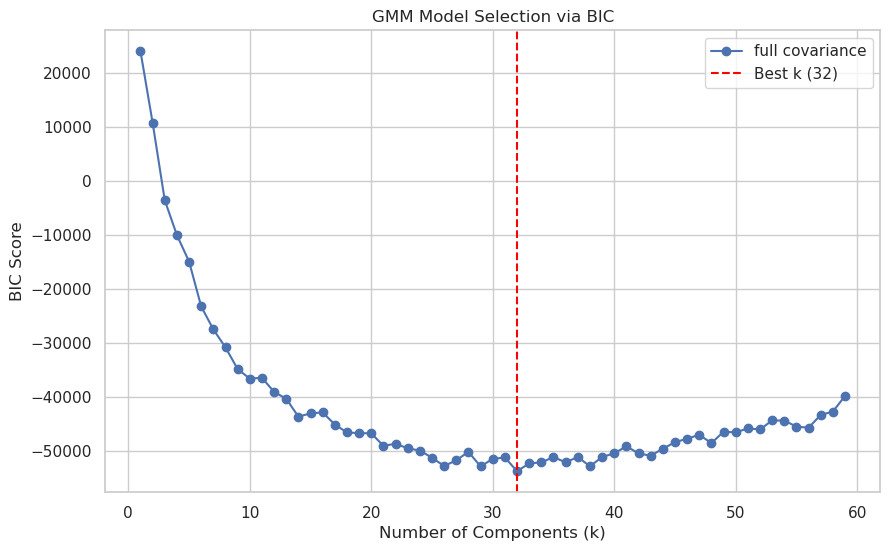

In [655]:
plt.figure(figsize=(10, 6))
for i, cov in enumerate(covariance_types):
    plt.plot(components, bics[i], label=f'{cov} covariance', marker='o')

plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("GMM Model Selection via BIC")
plt.axvline(x=min_bic_k, color='red', linestyle='--', label=f'Best k ({min_bic_k})')
plt.legend()
plt.grid(True)
plt.show()

In [656]:
bic_test_score = best_model.score(X_test)
bic_anom_score = best_model.score(X_anom_df)

print(f"{'Metric':<35}{'Lowest BIC model'}")
print("-" * 60)

print(f"{'Test data log-likelihood':<35}{bic_test_score:.2f}")
print(f"{'Anomaly data log-likelihood':<35}{bic_anom_score:.2f}")

Metric                             Lowest BIC model
------------------------------------------------------------
Test data log-likelihood           -10078.28
Anomaly data log-likelihood        -70289.39


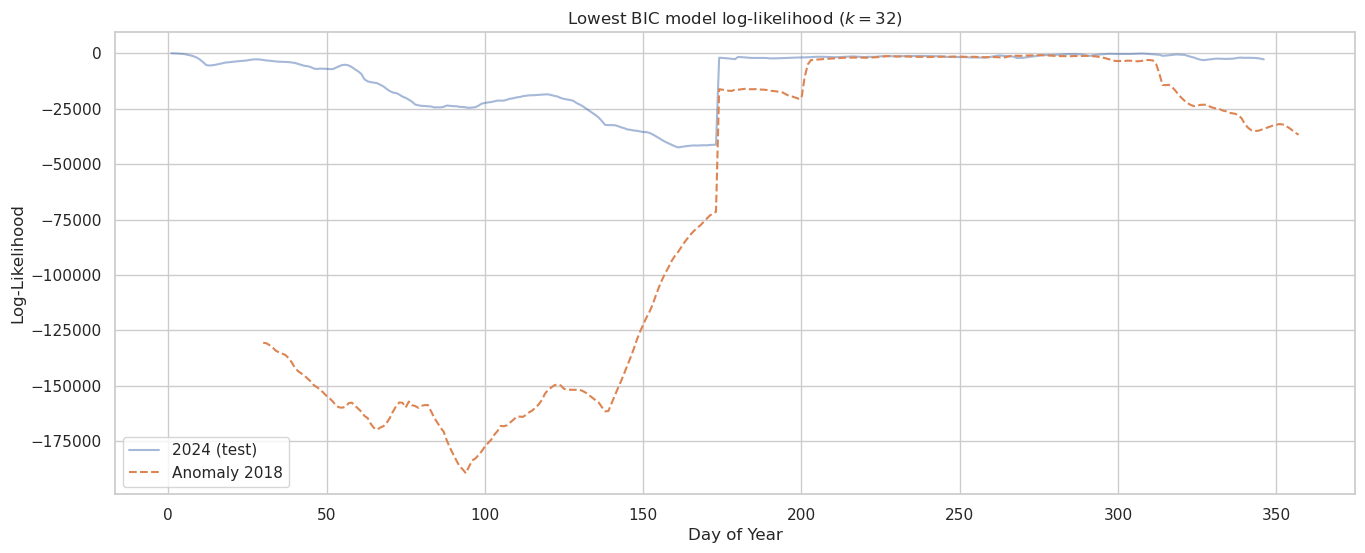

In [665]:
# Create a dataframe containing the scores and metadata
bic_test_scores = best_model.score_samples(X_test)
bic_anom_scores = best_model.score_samples(X_anom_df)

test_results = X_norm.iloc[split_i:][["year", "doy"]].copy()
test_results["log_likelihood"] = bic_test_scores

anom_results = X_anom[["year", "doy"]].copy()
anom_results["log_likelihood"] = bic_anom_scores

fig, ax = plt.subplots(figsize=(16, 6))

# Plot one line per year
for year, group in test_results.groupby("year"):
    group = group.sort_values("doy")
    sns.lineplot(
        data=group,
        x="doy",
        y="log_likelihood",
        ax=ax,
        label=f"{str(year)} (test)",
        alpha=0.5
    )

for year, group in anom_results.groupby("year"):
    group = group.sort_values("doy")
    sns.lineplot(
        data=group,
        x="doy",
        y="log_likelihood",
        ax=ax,
        linestyle="--",
        label=f"Anomaly {year}"
    )


ax.set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("Log-Likelihood")
plt.show()

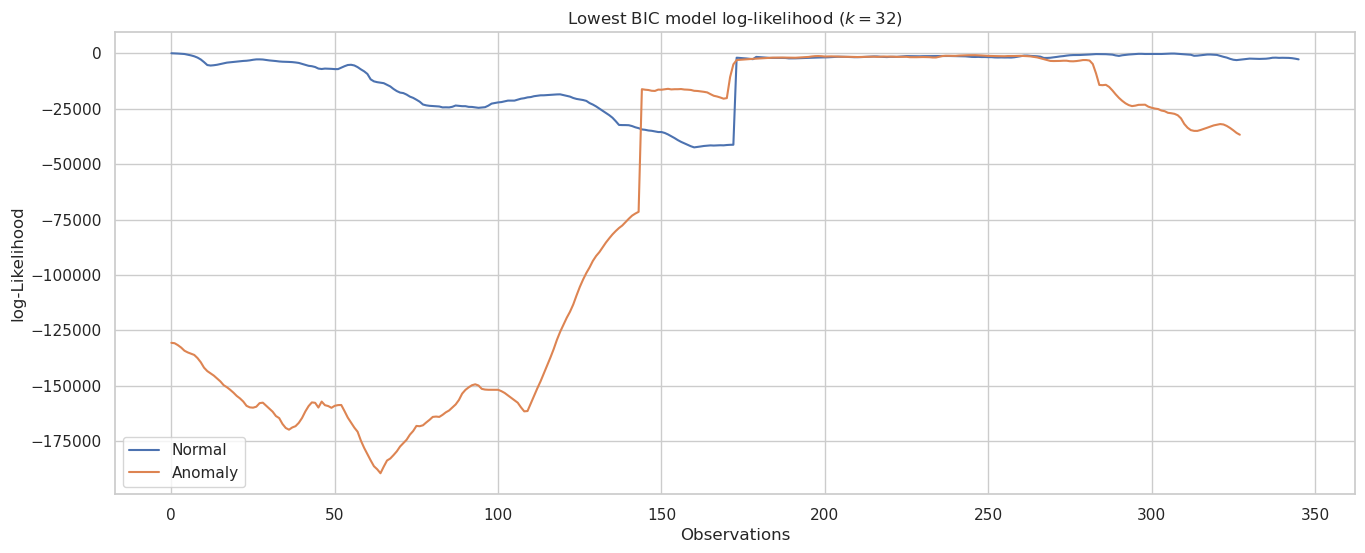

In [663]:
fig, ax = plt.subplots(ncols=1, figsize=(16, 6), sharey=False)
ax.set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
sns.lineplot(bic_test_scores, ax=ax, label="Normal")
sns.lineplot(bic_anom_scores[:len(X_test)], ax=ax, label="Anomaly")
ax.set_ylabel("log-Likelihood")
ax.set_xlabel("Observations")
plt.show()

We also create density plots to better showcase the separation abilities of the two models:

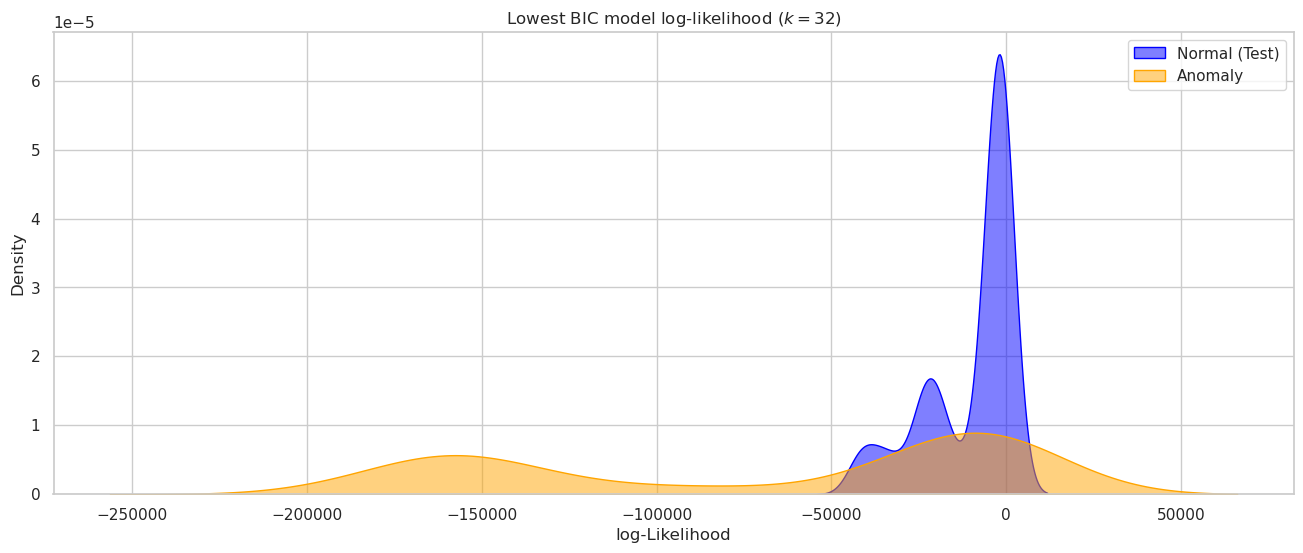

In [664]:
fig, ax = plt.subplots(ncols=1, figsize=(16, 6), sharey=False)
ax.set_title(f"Lowest BIC model log-likelihood ($k={min_bic_k}$)")
sns.kdeplot(bic_test_scores, label="Normal (Test)", fill=True, color="blue", alpha=0.5, ax=ax)
sns.kdeplot(bic_anom_scores, label="Anomaly", fill=True, color="orange", alpha=0.5, ax=ax)
ax.set_ylabel("Density")
ax.set_xlabel("log-Likelihood")
ax.legend()
plt.show()